# Metrics for classification

### Accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and when each one lies to you

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why accuracy collapses on unbalanced data, how every other metric falls out of the confusion matrix, why precision and recall belong to a threshold rather than to a model, when to read a ROC curve and when to read a precision-recall curve, what macro, micro and weighted averaging do on multiclass, and how to pick a threshold from the cost of each mistake |
| **You should already know** | [Train, validation, test](../02-train-validation-test/), [cross-validation](../04-cross-validation/) |
| **Datasets** | UCI Dry Bean, Wisconsin Breast Cancer |
| **Runtime** | Under two minutes on a laptop CPU |
| **Next** | [01-06 Metrics for regression](../06-metrics-for-regression/) |

---

## 1. The idea

A classifier does two separable things. It produces a **score** for each row, and
then a **threshold** turns that score into a decision. Almost every argument about
classification metrics is really an argument about which of those two you are
measuring.

Accuracy measures the decision. It counts the rows the model got right and divides
by the number of rows. That works when the classes are roughly the same size and
both kinds of mistake cost about the same. Neither of those holds often. Fraud,
disease, machine failure, click-through: the interesting class is usually the
rare one, and missing it usually costs far more than a false alarm.

When one class is rare, a model that never predicts it can still be right nearly
every time. It is right by refusing to answer the question. So I build exactly
that situation below, and then work through the metrics that survive it.

The plan: take the confusion matrix as the only primitive, derive precision,
recall and F1 from its four cells, then show that those three move as I slide the
threshold, which means they describe an operating point rather than a model. Two
curves summarise the whole sweep, ROC and precision-recall, and they disagree
sharply when positives are rare. Finally, the threshold gets chosen the way it
should be, from what each mistake costs.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

### A problem where accuracy is a lie

The Dry Bean data has seven varieties. I turn it into a binary problem, one
variety against the other six, and then subsample the positive class until it is
1% of the rows. SIRA is the variety that other notebooks find hardest to separate,
so the difficulty here comes from beans that genuinely look alike rather than from
noise I invented.

In [2]:
X_bean, y_bean = datasets.dry_bean()

POSITIVE = "SIRA"
rng = np.random.default_rng(SEED)

# 9,900 negatives and 100 positives, so "always negative" scores exactly 0.99.
positive_rows = rng.choice(np.flatnonzero((y_bean == POSITIVE).to_numpy()), 100, replace=False)
negative_rows = rng.choice(np.flatnonzero((y_bean != POSITIVE).to_numpy()), 9900, replace=False)
keep = np.concatenate([positive_rows, negative_rows])
rng.shuffle(keep)

X = X_bean.iloc[keep].reset_index(drop=True)
y = (y_bean.iloc[keep] == POSITIVE).astype(int).reset_index(drop=True).to_numpy()

print(f"rows          : {len(y):,}")
print(f"positives     : {y.sum()}  ({POSITIVE})")
print(f"positive rate : {y.mean():.2%}")

rows          : 10,000
positives     : 100  (SIRA)
positive rate : 1.00%


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)

# Out-of-fold probabilities: every row is scored by a model that never saw it, so
# this one array feeds every metric in the notebook without a separate holdout.
model = HistGradientBoostingClassifier(max_iter=200, random_state=SEED)
scores = cross_val_predict(model, X, y, cv=folds, method="predict_proba", n_jobs=-1)[:, 1]
predicted = (scores >= 0.5).astype(int)

dummy = cross_val_predict(DummyClassifier(strategy="most_frequent"), X, y, cv=folds, n_jobs=-1)

table = pd.DataFrame(
    [{"model": name,
      "accuracy": accuracy_score(y, pred),
      "precision": precision_score(y, pred, zero_division=0),
      "recall": recall_score(y, pred, zero_division=0),
      "f1": f1_score(y, pred, zero_division=0)}
     for name, pred in [("always predict negative", dummy), ("gradient boosting at 0.5", predicted)]]
).set_index("model")

print(table.round(4).to_string())
print(f"\nrows the model flagged as positive at 0.5: {predicted.sum()}")
print(f"real positives in the data               : {y.sum()}")

                          accuracy  precision  recall      f1
model                                                        
always predict negative      0.990     0.0000    0.00  0.0000
gradient boosting at 0.5     0.993     0.7344    0.47  0.5732

rows the model flagged as positive at 0.5: 64
real positives in the data               : 100


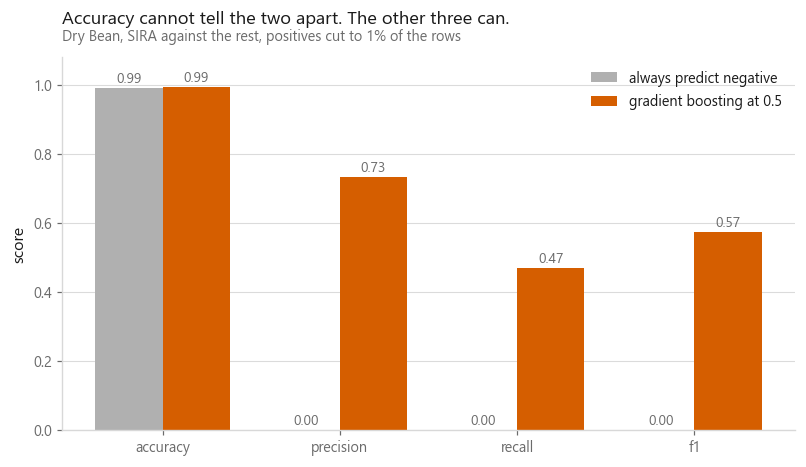

In [4]:
metrics = ["accuracy", "precision", "recall", "f1"]
positions = np.arange(len(metrics))
width = 0.38

fig, ax = plt.subplots(figsize=(8.6, 4.4))
bars_dummy = ax.bar(positions - width / 2, table.loc["always predict negative", metrics],
                    width, color=style.NEUTRAL, label="always predict negative")
bars_model = ax.bar(positions + width / 2, table.loc["gradient boosting at 0.5", metrics],
                    width, color=style.HIGHLIGHT, label="gradient boosting at 0.5")

for group in (bars_dummy, bars_model):
    for bar in group:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                f"{bar.get_height():.2f}", ha="center", fontsize=9, color=style.MUTED)

ax.set_xticks(positions, metrics)
ax.set_ylim(0, 1.08)
ax.set_ylabel("score")
ax.legend(loc="upper right")
style.title(ax, "Accuracy cannot tell the two apart. The other three can.",
            "Dry Bean, SIRA against the rest, positives cut to 1% of the rows")
style.save(fig, FIG / "fig-01-accuracy-lies.png")

The grey model has no parameters and never looks at a feature. It answers
"negative" to everything, and accuracy rewards it with the negative rate, which I
fixed at 0.99 when I built the data. Nothing about that number is earned.

Read the other three columns and the two models separate immediately, because
those three ignore the enormous pile of true negatives that accuracy is mostly
counting.

Two details worth pausing on. **Precision is undefined when a model predicts no
positives**: the denominator is the number of rows it flagged, which is zero.
scikit-learn prints 0 for that case when you pass `zero_division=0`, which is a
convention, not a measurement. And the model's own recall at the default
threshold is not something to be proud of either; that is section 3's problem.

## 2. The confusion matrix, from which everything else is derived

There is only one primitive here. Cross the truth against the prediction and count
the four combinations.

true negatives   9,883   false positives    17
false negatives     53   true positives     47


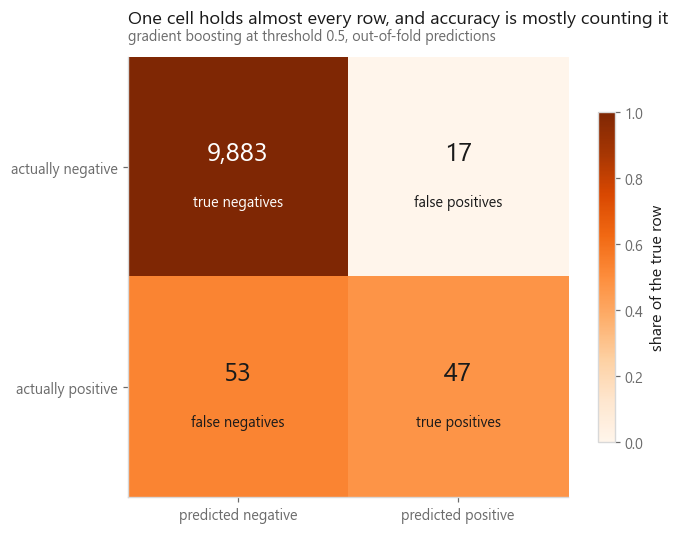

In [5]:
from sklearn.metrics import confusion_matrix

matrix = confusion_matrix(y, predicted)
tn, fp, fn, tp = matrix.ravel()

# Colour by share of the true row so the picture stays readable, but print counts,
# because the size of the true-negative pile is the thing worth seeing.
shares = matrix / matrix.sum(axis=1, keepdims=True)
names = [["true negatives", "false positives"], ["false negatives", "true positives"]]

fig, ax = plt.subplots(figsize=(7.0, 5.2))
image = ax.imshow(shares, cmap="Oranges", vmin=0, vmax=1)

for i in range(2):
    for j in range(2):
        ink = "white" if shares[i, j] > 0.55 else style.INK
        ax.text(j, i - 0.06, f"{matrix[i, j]:,}", ha="center", va="center",
                fontsize=17, color=ink)
        ax.text(j, i + 0.16, names[i][j], ha="center", va="center",
                fontsize=9.5, color=ink)

ax.set_xticks([0, 1], ["predicted negative", "predicted positive"])
ax.set_yticks([0, 1], ["actually negative", "actually positive"])
ax.grid(False)
fig.colorbar(image, ax=ax, shrink=0.75, label="share of the true row")
style.title(ax, "One cell holds almost every row, and accuracy is mostly counting it",
            "gradient boosting at threshold 0.5, out-of-fold predictions")
style.save(fig, FIG / "fig-02-confusion-matrix.png")

print(f"true negatives  {tn:>6,}   false positives {fp:>5,}")
print(f"false negatives {fn:>6,}   true positives  {tp:>5,}")

Write the four counts as $TN$, $FP$, $FN$, $TP$ and every metric in this notebook
is one line of arithmetic on them.

$$\text{accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
\qquad
\text{precision} = \frac{TP}{TP + FP}
\qquad
\text{recall} = \frac{TP}{TP + FN}$$

Precision divides by the column: of everything I flagged, how much was real.
Recall divides by the row: of everything real, how much did I catch. Accuracy
divides by the whole table, which is why a huge $TN$ drowns it.

F1 is the harmonic mean of precision and recall:

$$F_1 = \frac{2PR}{P + R} = \frac{2TP}{2TP + FP + FN}$$

The right-hand form is the one I compute, because it stays defined when a model
flags nothing. The harmonic mean is chosen over the plain average because it
punishes imbalance: a model with precision 1.0 and recall 0.0 averages 0.5 the
ordinary way and scores 0 the harmonic way, and 0 is the honest answer.

Two more that section 4 needs, both read off the same table:

$$\text{TPR} = \text{recall} = \frac{TP}{TP + FN}
\qquad
\text{FPR} = \frac{FP}{FP + TN}$$

In [6]:
def safe_div(numerator, denominator):
    """Division that reports an undefined metric as nan instead of silently zero."""
    return numerator / denominator if denominator else float("nan")


by_hand = {
    "accuracy": (tp + tn) / matrix.sum(),
    "precision": safe_div(tp, tp + fp),
    "recall": safe_div(tp, tp + fn),
    "f1": safe_div(2 * tp, 2 * tp + fp + fn),
    "specificity": safe_div(tn, tn + fp),
    "false positive rate": safe_div(fp, fp + tn),
}
from_sklearn = {
    "accuracy": accuracy_score(y, predicted),
    "precision": precision_score(y, predicted, zero_division=0),
    "recall": recall_score(y, predicted, zero_division=0),
    "f1": f1_score(y, predicted, zero_division=0),
}

for name, value in by_hand.items():
    match = from_sklearn.get(name)
    check = "" if match is None else f"   sklearn {match:.6f}"
    print(f"{name:<20} {value:.6f}{check}")

accuracy             0.993000   sklearn 0.993000
precision            0.734375   sklearn 0.734375
recall               0.470000   sklearn 0.470000
f1                   0.573171   sklearn 0.573171
specificity          0.998283
false positive rate  0.001717


The four cells reproduce scikit-learn exactly, because there is nothing else in
there. Any time a metric surprises you, print the confusion matrix and the
surprise usually explains itself.

## 3. Threshold is a choice, not a property

The model handed me a probability per row. Everything in section 2 came from
comparing it against 0.5, and 0.5 is a default, not a finding. Slide it and the
same model, with the same scores and the same ranking, produces a different
precision and a different recall.

           flagged  precision  recall      f1
threshold                                    
0.02            98     0.5816    0.57  0.5758
0.05            89     0.6180    0.55  0.5820
0.10            84     0.6548    0.55  0.5978
0.25            74     0.7027    0.52  0.5977
0.50            64     0.7344    0.47  0.5732

best F1 threshold: 0.1662  (precision 0.7051, recall 0.5500, F1 0.6180)


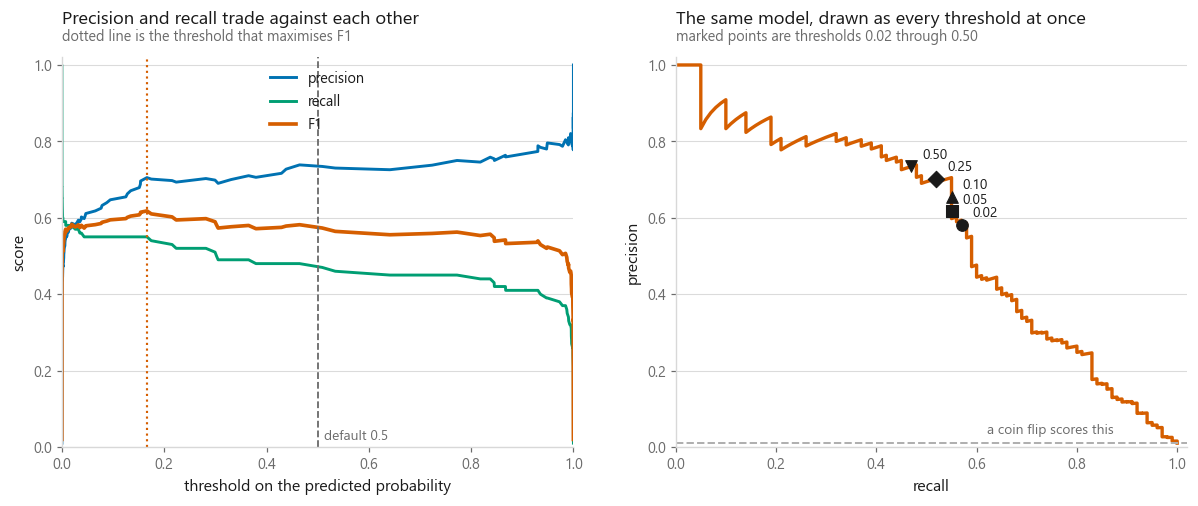

In [7]:
from sklearn.metrics import precision_recall_curve

precision_curve, recall_curve, thresholds = precision_recall_curve(y, scores)
f1_curve = np.divide(2 * precision_curve * recall_curve,
                     precision_curve + recall_curve,
                     out=np.zeros_like(precision_curve),
                     where=(precision_curve + recall_curve) > 0)

best = int(np.argmax(f1_curve[:-1]))
best_threshold = thresholds[best]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.6))

axes[0].plot(thresholds, precision_curve[:-1], color=style.PALETTE[0], label="precision")
axes[0].plot(thresholds, recall_curve[:-1], color=style.PALETTE[2], label="recall")
axes[0].plot(thresholds, f1_curve[:-1], color=style.HIGHLIGHT, lw=2.4, label="F1")
axes[0].axvline(0.5, color=style.MUTED, ls="--", lw=1.2)
axes[0].axvline(best_threshold, color=style.HIGHLIGHT, ls=":", lw=1.4)
axes[0].annotate("default 0.5", xy=(0.5, 0.02), xytext=(4, 0), textcoords="offset points",
                 fontsize=9, color=style.MUTED)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel("threshold on the predicted probability")
axes[0].set_ylabel("score")
axes[0].legend(loc="upper center")
style.title(axes[0], "Precision and recall trade against each other",
            "dotted line is the threshold that maximises F1")

marks = [0.02, 0.05, 0.10, 0.25, 0.50]
axes[1].plot(recall_curve, precision_curve, color=style.HIGHLIGHT, lw=2.2)
axes[1].axhline(y.mean(), color=style.NEUTRAL, ls="--", lw=1.3)
axes[1].annotate("a coin flip scores this", xy=(0.62, y.mean()), xytext=(0, 6),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
for i, t in enumerate(marks):
    flagged = (scores >= t).astype(int)
    axes[1].scatter(recall_score(y, flagged, zero_division=0),
                    precision_score(y, flagged, zero_division=0),
                    marker=style.MARKERS[i], s=58, color=style.INK, zorder=3)
    axes[1].annotate(f"{t:.2f}",
                     xy=(recall_score(y, flagged, zero_division=0),
                         precision_score(y, flagged, zero_division=0)),
                     xytext=(7, 5), textcoords="offset points", fontsize=9, color=style.INK)
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
style.title(axes[1], "The same model, drawn as every threshold at once",
            "marked points are thresholds 0.02 through 0.50")

style.save(fig, FIG / "fig-03-threshold-tradeoff.png")

operating = pd.DataFrame(
    [{"threshold": t,
      "flagged": int((scores >= t).sum()),
      "precision": precision_score(y, (scores >= t).astype(int), zero_division=0),
      "recall": recall_score(y, (scores >= t).astype(int), zero_division=0),
      "f1": f1_score(y, (scores >= t).astype(int), zero_division=0)}
     for t in marks]
).set_index("threshold")
print(operating.round(4).to_string())
print(f"\nbest F1 threshold: {best_threshold:.4f}  "
      f"(precision {precision_curve[best]:.4f}, recall {recall_curve[best]:.4f}, "
      f"F1 {f1_curve[best]:.4f})")

Nothing about the model changed across that table. The weights are identical, the
ranking of the rows is identical, and only the line I drew through the scores
moved. So "this model has precision $p$" is an incomplete sentence. The complete
one names a threshold.

Lowering the threshold flags more rows: recall can only go up, precision usually
goes down, because the extra rows you sweep in are the ones the model was least
sure about. Raising it does the reverse. F1 sits in between and has a maximum
somewhere, which is a reasonable default when you have no cost information, and a
poor one when you do, as section 5 shows.

The right panel is the whole sweep drawn as one line. Each point on it is a
threshold. Choosing a threshold means choosing a point on that curve, and no
amount of retraining moves you along it; only the choice does.

The curve is visibly stepped near the high-precision end. With this few positives,
each one caught or missed moves recall by a full percentage point, and the curve
inherits that coarseness. Rare-positive estimates are noisy estimates, and drawing
them smooth would hide that.

## 4. ROC against precision-recall

Two curves summarise the sweep. **ROC** plots true positive rate against false
positive rate. **Precision-recall** plots precision against recall. They use the
same scores and the same thresholds, so it is fair to ask why anyone needs both.

The answer is in the denominators. Both ROC axes divide within a class: TPR by the
positives, FPR by the negatives. Change the mix of positives and negatives in your
test set and neither axis moves in expectation. Precision does not have that
property: its denominator mixes $TP$ and $FP$, so it depends directly on how many
negatives there are to generate false positives from.

I can demonstrate that with no new model at all. I take the scores I already have
and evaluate them twice: once on all 10,000 rows at 1% positives, and once on a
subset holding every positive and an equal number of negatives. Identical model,
identical scores, only the prevalence differs.

1% positives (all rows)                ROC-AUC 0.9699   PR-AUC 0.5708   baseline PR-AUC 0.0100
50% positives (negatives subsampled)   ROC-AUC 0.9614   PR-AUC 0.9558   baseline PR-AUC 0.5000


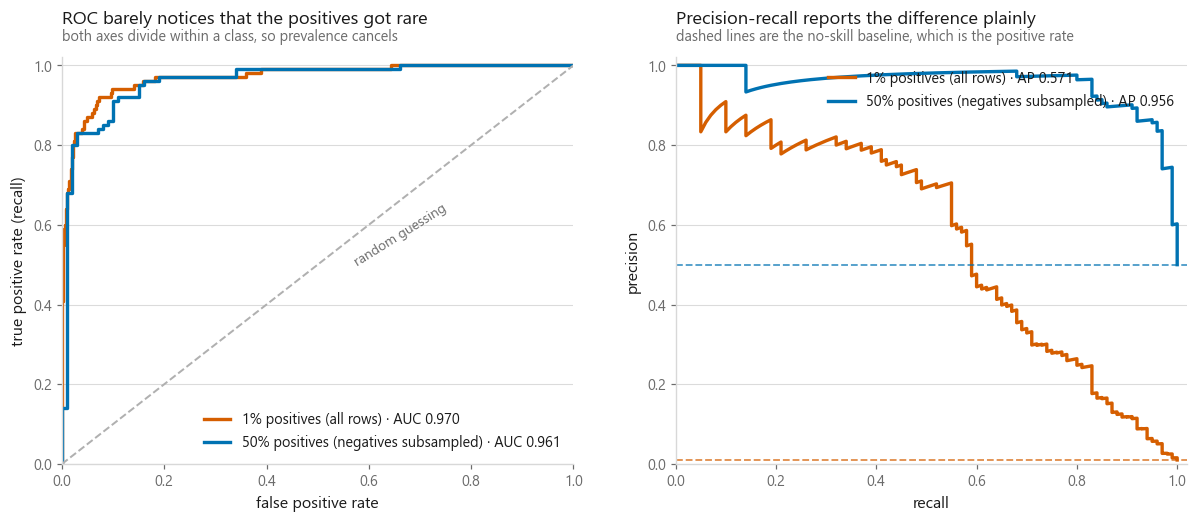

In [8]:
from sklearn.metrics import average_precision_score, roc_auc_score, roc_curve

positives_idx = np.flatnonzero(y == 1)
negatives_idx = np.flatnonzero(y == 0)
balanced = np.concatenate([positives_idx,
                           np.random.default_rng(SEED).choice(negatives_idx,
                                                              len(positives_idx), replace=False)])

views = {
    "1% positives (all rows)": (y, scores),
    "50% positives (negatives subsampled)": (y[balanced], scores[balanced]),
}
colours = [style.HIGHLIGHT, style.PALETTE[0]]

fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

for (label, (truth, score)), colour in zip(views.items(), colours):
    fpr, tpr, _ = roc_curve(truth, score)
    axes[0].plot(fpr, tpr, color=colour, lw=2.2,
                 label=f"{label} · AUC {roc_auc_score(truth, score):.3f}")

    prec, rec, _ = precision_recall_curve(truth, score)
    axes[1].plot(rec, prec, color=colour, lw=2.2,
                 label=f"{label} · AP {average_precision_score(truth, score):.3f}")
    axes[1].axhline(truth.mean(), color=colour, ls="--", lw=1.2, alpha=0.7)

axes[0].plot([0, 1], [0, 1], color=style.NEUTRAL, ls="--", lw=1.3)
axes[0].annotate("random guessing", xy=(0.55, 0.55), xytext=(6, -14),
                 textcoords="offset points", fontsize=9, color=style.MUTED, rotation=32)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate (recall)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].legend(loc="lower right")
style.title(axes[0], "ROC barely notices that the positives got rare",
            "both axes divide within a class, so prevalence cancels")

axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_xlim(0, 1.02)
axes[1].set_ylim(0, 1.02)
axes[1].legend(loc="upper right")
style.title(axes[1], "Precision-recall reports the difference plainly",
            "dashed lines are the no-skill baseline, which is the positive rate")

style.save(fig, FIG / "fig-04-roc-vs-pr.png")

for label, (truth, score) in views.items():
    print(f"{label:<38} ROC-AUC {roc_auc_score(truth, score):.4f}   "
          f"PR-AUC {average_precision_score(truth, score):.4f}   "
          f"baseline PR-AUC {truth.mean():.4f}")

In [9]:
# Repeat the subsampling twenty times so the comparison is not one lucky draw.
repeat_auc, repeat_ap = [], []
for offset in range(20):
    draw = np.random.default_rng(100 + offset).choice(negatives_idx, len(positives_idx), replace=False)
    rows = np.concatenate([positives_idx, draw])
    repeat_auc.append(roc_auc_score(y[rows], scores[rows]))
    repeat_ap.append(average_precision_score(y[rows], scores[rows]))

print(f"ROC-AUC at 1% positives  : {roc_auc_score(y, scores):.4f}")
print(f"ROC-AUC at 50% positives : {np.mean(repeat_auc):.4f} +/- {np.std(repeat_auc):.4f}  (20 draws)")
print(f"PR-AUC  at 1% positives  : {average_precision_score(y, scores):.4f}")
print(f"PR-AUC  at 50% positives : {np.mean(repeat_ap):.4f} +/- {np.std(repeat_ap):.4f}  (20 draws)")

ROC-AUC at 1% positives  : 0.9699
ROC-AUC at 50% positives : 0.9699 +/- 0.0045  (20 draws)
PR-AUC  at 1% positives  : 0.5708
PR-AUC  at 50% positives : 0.9728 +/- 0.0046  (20 draws)


In [10]:
# ROC-AUC has a reading with no curve in it: the chance a random positive is scored
# above a random negative. 100 x 9,900 pairs is small enough to just enumerate.
differences = scores[y == 1][:, None] - scores[y == 0][None, :]
auc_by_pairs = (differences > 0).mean() + 0.5 * (differences == 0).mean()

print(f"pairs compared        : {differences.size:,}")
print(f"AUC by counting pairs : {auc_by_pairs:.6f}")
print(f"AUC from scikit-learn : {roc_auc_score(y, scores):.6f}")

pairs compared        : 990,000
AUC by counting pairs : 0.969935
AUC from scikit-learn : 0.969935


The two ROC curves sit almost on top of each other and the two AUCs agree to
roughly the noise of the resampling. The precision-recall curves are far apart,
and their baselines are far apart too: a coin flip earns precision equal to the
positive rate, so the bar a model has to clear drops as positives get rarer. PR-AUC
is scored against a moving floor and ROC-AUC is not.

That is the whole argument for preferring precision-recall when positives are rare.
A high ROC-AUC is compatible with a false positive rate that looks tiny as a
fraction of negatives and enormous as a count, because there are so many negatives.
Precision counts that pile directly, so it is the number your on-call engineer
feels.

The pair-counting cell gives ROC-AUC its plain-language reading: pick one positive
and one negative at random, and AUC is the probability the model ranks the positive
higher. It says nothing about the threshold, which is a strength when you are
comparing rankings and a weakness when you have to ship a decision.

So: **ROC-AUC to compare rankings across models, PR-AUC to judge whether the
ranking is any use at the rate your positives actually occur.** Report both and
nobody can be misled by either.

## 5. Multiclass averaging, and choosing a threshold from costs

### Macro, micro and weighted

Precision and recall are defined for one class against the rest. With seven
classes there are seven of each, and collapsing them into a single number takes a
choice.

**Macro** averages the per-class scores with equal weight, so the smallest class
counts as much as the largest. **Micro** pools the counts first (add up all the
$TP$, all the $FP$, all the $FN$ across classes, then apply the formula once), so
every row counts the same and the big classes dominate. **Weighted** averages the
per-class scores using class size as the weight.

The full Dry Bean data is naturally unbalanced, so the three answers separate.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_fscore_support
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

multiclass = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
bean_predicted = cross_val_predict(multiclass, X_bean.values, y_bean.values,
                                   cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                                   n_jobs=-1)

labels = sorted(y_bean.unique())
p, r, f, support = precision_recall_fscore_support(y_bean, bean_predicted,
                                                   labels=labels, zero_division=0)
per_class = pd.DataFrame({"precision": p, "recall": r, "f1": f, "support": support},
                         index=labels).sort_values("support")
print("per class, smallest first:")
print(per_class.round(3).to_string())

averaged = pd.DataFrame(
    [dict(zip(["precision", "recall", "f1"],
              precision_recall_fscore_support(y_bean, bean_predicted, average=how,
                                              zero_division=0)[:3]),
          average=how)
     for how in ["macro", "micro", "weighted"]]
).set_index("average")
print("\n" + averaged.round(4).to_string())
print(f"\nplain accuracy: {accuracy_score(y_bean, bean_predicted):.4f}")

per class, smallest first:
          precision  recall     f1  support
BOMBAY        1.000   1.000  1.000      522
BARBUNYA      0.942   0.904  0.923     1322
CALI          0.932   0.944  0.938     1630
HOROZ         0.954   0.952  0.953     1928
SEKER         0.947   0.947  0.947     2027
SIRA          0.856   0.877  0.866     2636
DERMASON      0.923   0.915  0.919     3546

          precision  recall      f1
average                            
macro        0.9362  0.9341  0.9351
micro        0.9234  0.9234  0.9234
weighted     0.9238  0.9234  0.9235

plain accuracy: 0.9234


Micro-averaged precision, micro-averaged recall and accuracy come out identical,
and that is not a coincidence. When each row gets exactly one predicted label,
every mistake is a false positive for one class and a false negative for another,
so the pooled counts satisfy $\sum FP = \sum FN$ and all three formulas reduce to
the fraction of rows that were right. Reporting micro-F1 alongside accuracy on a
single-label problem tells the reader one number twice.

Macro is the one that carries information accuracy does not, and the direction it
moves is diagnostic. If macro sits below micro, the small classes are the hard
ones and the headline number is being propped up by the big ones. If macro sits
above, the small classes are the easy ones, which happens more often than people
expect, because rarity and difficulty are separate things. Read the per-class
table above before assuming either.

Weighted is the compromise, and I find it the least useful of the three. It weights
each class by its size, which pulls it back toward the answer accuracy already gave
me, in exactly the situation where I wanted a number that would not do that.

### Choosing a threshold from costs

Back to binary, and to the question section 3 left open. If precision and recall
come from a threshold, and the threshold is mine to pick, what should I pick it
with? Not F1, unless the two mistakes really do cost the same.

Say a false negative costs $c_{FN}$ and a false positive costs $c_{FP}$. For a row
with predicted probability $p$, flagging it is worth doing when the expected cost
of staying silent exceeds the expected cost of speaking up:

$$p \cdot c_{FN} > (1 - p) \cdot c_{FP}
\qquad\Longrightarrow\qquad
p > \frac{c_{FP}}{c_{FP} + c_{FN}}$$

So the cost-optimal threshold is $c_{FP} / (c_{FP} + c_{FN})$, and 0.5 is the
special case where the two costs are equal. That formula assumes the probabilities
are calibrated, which is a real assumption, so I also sweep the threshold and
measure the cost directly.

Breast cancer is the honest place for this. Missing a malignant tumour and calling
a benign one malignant are not comparable errors.

In [12]:
X_cancer, y_cancer = datasets.breast_cancer()

# scikit-learn ships this target as 1 = benign. The event worth catching is the
# malignant one, so flip it -- otherwise every metric below describes the wrong class.
y_malignant = (y_cancer == 0).astype(int).to_numpy()

cancer_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000))
cancer_scores = cross_val_predict(cancer_model, X_cancer.values, y_malignant,
                                  cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                                  method="predict_proba", n_jobs=-1)[:, 1]

print(f"rows: {len(y_malignant)}   malignant: {y_malignant.sum()}  "
      f"({y_malignant.mean():.1%})")
print(f"ROC-AUC {roc_auc_score(y_malignant, cancer_scores):.4f}   "
      f"PR-AUC {average_precision_score(y_malignant, cancer_scores):.4f}")

rows: 569   malignant: 212  (37.3%)
ROC-AUC 0.9953   PR-AUC 0.9942


            theory threshold  measured best  cost at best  cost at 0.50  excess at 0.50
cost ratio                                                                             
1:1                   0.5000          0.485        0.0193        0.0211          0.0909
5:1                   0.1667          0.195        0.0668        0.0844          0.2632
20:1                  0.0476          0.060        0.1230        0.3216          1.6143


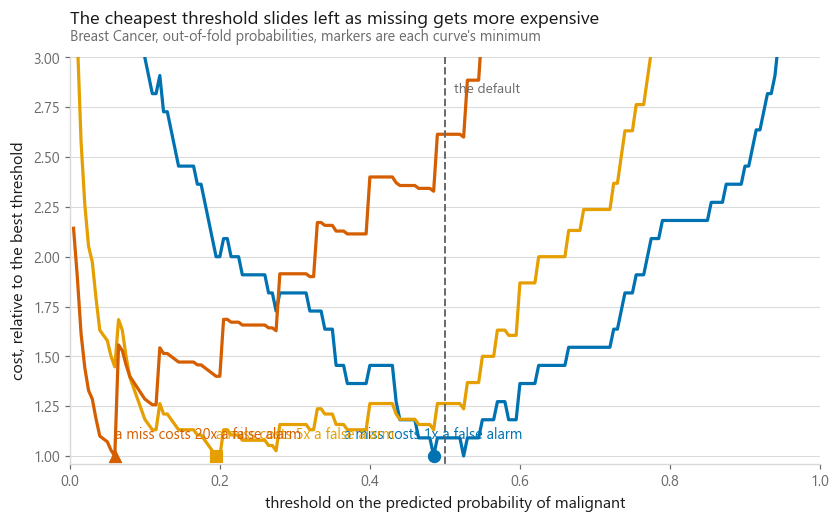

In [13]:
grid = np.linspace(0.005, 0.995, 199)
ratios = [1, 5, 20]

fig, ax = plt.subplots(figsize=(8.8, 4.8))
summary = []

for i, ratio in enumerate(ratios):
    cost = np.array([
        (ratio * np.sum((cancer_scores < t) & (y_malignant == 1))
         + np.sum((cancer_scores >= t) & (y_malignant == 0))) / len(y_malignant)
        for t in grid])
    cheapest = int(np.argmin(cost))
    cost_at_half = cost[int(np.argmin(np.abs(grid - 0.5)))]

    colour = style.HIGHLIGHT if ratio == max(ratios) else style.PALETTE[i]
    ax.plot(grid, cost / cost[cheapest], color=colour, lw=2.1)
    ax.scatter(grid[cheapest], 1.0, marker=style.MARKERS[i], s=64, color=colour, zorder=3)
    # Label each curve at its own minimum rather than in a legend, so the reader
    # does not have to match colours across the chart.
    ax.annotate(f"a miss costs {ratio}x a false alarm",
                xy=(grid[cheapest], 1.0), xytext=(0, 11), textcoords="offset points",
                ha="left" if grid[cheapest] < 0.25 else "center",
                fontsize=9.5, color=colour)

    summary.append({"cost ratio": f"{ratio}:1",
                    "theory threshold": 1 / (1 + ratio),
                    "measured best": grid[cheapest],
                    "cost at best": cost[cheapest],
                    "cost at 0.50": cost_at_half,
                    "excess at 0.50": cost_at_half / cost[cheapest] - 1})

ax.axvline(0.5, color=style.MUTED, ls="--", lw=1.3)
ax.annotate("the default", xy=(0.5, 2.82), xytext=(6, 0), textcoords="offset points",
            fontsize=9, color=style.MUTED)
ax.set_xlim(0, 1)
ax.set_ylim(0.96, 3.0)
ax.set_xlabel("threshold on the predicted probability of malignant")
ax.set_ylabel("cost, relative to the best threshold")
style.title(ax, "The cheapest threshold slides left as missing gets more expensive",
            "Breast Cancer, out-of-fold probabilities, markers are each curve's minimum")
style.save(fig, FIG / "fig-05-cost-threshold.png")

print(pd.DataFrame(summary).set_index("cost ratio").round(4).to_string())

How close the measured minimum sits to the formula's $c_{FP}/(c_{FP}+c_{FN})$ is a
quiet check on the probabilities, because the formula only holds if they are
calibrated. Expect the sweep's answer to be blurry either way: the cost function is
a step function over a few hundred rows, so its minimum sits in a flat valley
rather than at a point, and the exact bottom of that valley moves with the sample.
Where the two disagree, trust the sweep: it measured the cost, the formula assumed
calibration.

The last column is the price of the default. At equal costs the formula returns
0.5, so the default is already the deliberate choice and there is little to gain.
As a miss gets more expensive the minimum walks left, the default stops moving, and
the gap between them is paid in false negatives that were cheap to avoid.

The threshold has to come from somewhere. If you do not choose it deliberately,
you have chosen 0.5 and asserted that the two mistakes cost the same. On most
problems worth solving, they do not.

One caution: pick the threshold on validation data, never on the test set. It is a
fitted parameter like any other, and tuning it on the same rows you report from
will flatter the result. The sweeps above run on out-of-fold predictions for that
reason.

## Cheat sheet

| | |
|---|---|
| **Accuracy** | Fine when classes are balanced and mistakes cost the same. Otherwise compare it against the majority-class rate before believing it |
| **Precision** | Of what I flagged, how much was real. Undefined when nothing is flagged |
| **Recall** | Of what was real, how much I caught. Also called sensitivity or TPR |
| **F1** | Harmonic mean of the two. A default when costs are unknown, a mistake when they are known |
| **ROC-AUC** | Probability a random positive outranks a random negative. Threshold-free, prevalence-free, and unmoved by rare positives |
| **PR-AUC** | Area under precision against recall. Baseline is the positive rate, so read it against that baseline rather than against 1.0 |
| **Rare positives** | Report PR-AUC. ROC-AUC will look good while the alert queue is mostly noise |
| **Multiclass** | Macro treats classes equally, micro treats rows equally and equals accuracy for single-label problems, weighted sits between |
| **Threshold** | Set it from $c_{FP}/(c_{FP}+c_{FN})$ or from a measured cost sweep, on validation data, never on test |
| **Next** | [Metrics for regression](../06-metrics-for-regression/), where the same argument replays with MAE against RMSE |

## What to remember

1. On unbalanced data, accuracy measures the size of the majority class more than
   it measures the model. Always compare against the majority-class baseline.
2. The confusion matrix is the only primitive. Precision, recall, F1, TPR and FPR
   are four counts rearranged.
3. Precision and recall belong to a threshold, not to a model. Naming one without
   the other is an incomplete sentence.
4. ROC axes divide within a class, so ROC-AUC ignores prevalence. Precision does
   not, which is why precision-recall is the honest curve when positives are rare.
5. Micro-averaged F1 equals accuracy on single-label multiclass. Macro is the one
   that tells you something new, and it can land either side of micro.
6. Choose the threshold from what the two mistakes cost. Accepting 0.5 is
   accepting that they cost the same.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [01-06 Metrics for regression](../06-metrics-for-regression/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Metrics` `#PrecisionRecall` `#ROCAUC` `#ClassImbalance`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#ModelEvaluation`